In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#additional_time_ratio = 1.05
#str_t = ("%.2f" % additional_time_ratio).replace(".", "")
dir_path = '../../data/npy_result'
common_name = 'imagenet_resnet18_e105'

def load_npy(filename: str):
    return np.load(filename, allow_pickle=True).item()

def print_results(key, npy):
    best = np.argmax(npy['val_acc'])
    print(
        f'{key},',
        f'time: {npy["commit_time"][-1]: .1f},',
        f'loss: {npy["val_loss"][-1]: .3f},',
        f'acc: {round(npy["val_acc"][-1] * 100, 1)}%,',
        f'index: {best},',
        f'best_loss: {npy["val_loss"][best]: .3f},',
        f'best_acc: {round(npy["val_acc"][best] * 100, 1)}%'
    )

In [3]:
npy = {
    'conf': {
        #'single': load_npy(f'{dir_path}/conf_{common_name}_t105_w2s0_amp.npy'),
        's0': load_npy(f'{dir_path}/conf_{common_name}_t105_w5s0_amp.npy'),
        't105': {
            's1': load_npy(f'{dir_path}/conf_{common_name}_t105_w5s1_amp.npy'),
            's2': load_npy(f'{dir_path}/conf_{common_name}_t105_w5s2_amp.npy'),
            's3': load_npy(f'{dir_path}/conf_{common_name}_t105_w5s3_amp.npy'),
            's4': load_npy(f'{dir_path}/conf_{common_name}_t105_w5s4_amp.npy'),
        },
        't110': {
            's1': load_npy(f'{dir_path}/conf_{common_name}_t110_w5s1_amp.npy'),
            's2': load_npy(f'{dir_path}/conf_{common_name}_t110_w5s2_amp.npy'),
            's3': load_npy(f'{dir_path}/conf_{common_name}_t110_w5s3_amp.npy'),
            's4': load_npy(f'{dir_path}/conf_{common_name}_t110_w5s4_amp.npy'),
        },
    },
    'journal': {
        #'single': load_npy(f'{dir_path}/{common_name}_t105_w2s0_amp.npy'),
        's0': load_npy(f'{dir_path}/{common_name}_t105_w5s0_amp.npy'),
        't105': {
            's1': load_npy(f'{dir_path}/{common_name}_t105_w5s1_amp.npy'),
            's2': load_npy(f'{dir_path}/{common_name}_t105_w5s2_amp.npy'),
            's3': load_npy(f'{dir_path}/{common_name}_t105_w5s3_amp.npy'),
            's4': load_npy(f'{dir_path}/{common_name}_t105_w5s4_amp.npy'),
        },
        't110': {
            's1': load_npy(f'{dir_path}/{common_name}_t110_w5s1_amp.npy'),
            's2': load_npy(f'{dir_path}/{common_name}_t110_w5s2_amp.npy'),
            's3': load_npy(f'{dir_path}/{common_name}_t110_w5s3_amp.npy'),
            's4': load_npy(f'{dir_path}/{common_name}_t110_w5s4_amp.npy'),
        },
    },
}

In [4]:
print(npy['journal']['t105']['s1'].keys())

dict_keys(['worker_ID', 'global_commit_ID', 'local_commit_ID', 'step_ID', 'stage_ID', 'train_loss', 'train_acc', 'train_time', 'val_loss', 'val_acc', 'commit_time'])


### Result

In [5]:
for key1, value1 in npy.items():
    print(key1)
    #print_results('single', value1['single'])
    print_results('s0', value1['s0'])
    print('- t105')
    for key2, value2 in value1['t105'].items():
        print_results(key2, value2)
    print('- t110')
    for key2, value2 in value1['t110'].items():
        print_results(key2, value2)
    print('====')

conf
s0, time:  33974.6, loss:  1.869, acc: 65.8%, index: 395, best_loss:  1.874, best_acc: 65.9%
- t105
s1, time:  34454.0, loss:  2.219, acc: 61.9%, index: 415, best_loss:  2.226, best_acc: 62.1%
s2, time:  34203.7, loss:  2.027, acc: 64.5%, index: 414, best_loss:  2.032, best_acc: 64.5%
s3, time:  33997.3, loss:  1.917, acc: 65.6%, index: 407, best_loss:  1.926, best_acc: 65.7%
s4, time:  33917.9, loss:  1.906, acc: 65.4%, index: 413, best_loss:  1.913, best_acc: 65.5%
- t110
s1, time:  34996.8, loss:  2.395, acc: 60.7%, index: 409, best_loss:  2.413, best_acc: 60.8%
s2, time:  34688.0, loss:  2.197, acc: 62.1%, index: 417, best_loss:  2.195, best_acc: 62.5%
s3, time:  34908.3, loss:  2.057, acc: 63.5%, index: 407, best_loss:  2.067, best_acc: 63.9%
s4, time:  34748.8, loss:  1.984, acc: 64.8%, index: 416, best_loss:  1.990, best_acc: 64.9%
====
journal
s0, time:  21757.8, loss:  1.955, acc: 65.0%, index: 417, best_loss:  1.949, best_acc: 65.1%
- t105
s1, time:  22160.9, loss:  2.13

### Plot

In [6]:
SAVE = True
DPI = 300 if SAVE else 72 # [72, 150, 240, 300]
fig_data = 'imagenet'
fig_path = '../fig'

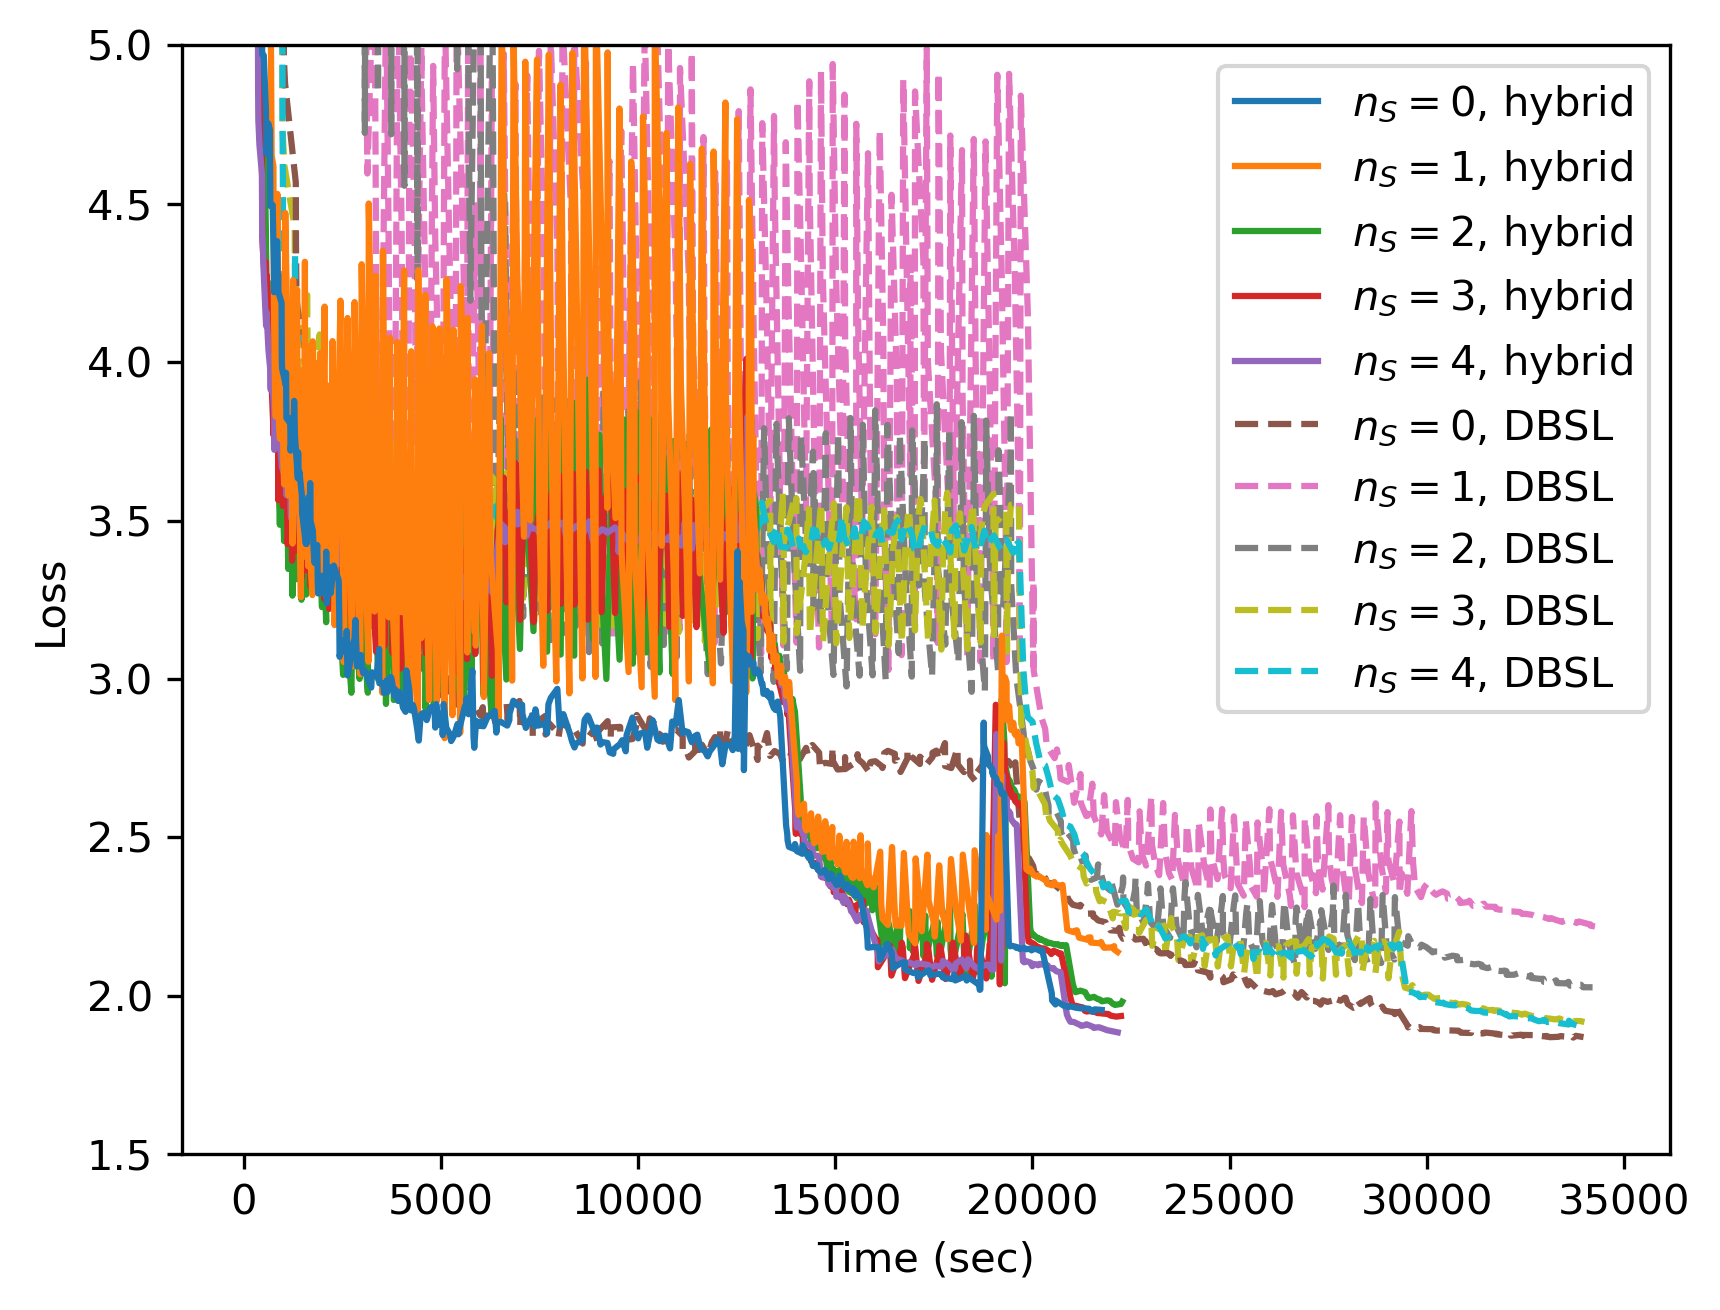

In [7]:
tag = 't105'
feature = 'val_loss'
fig_name = f'{fig_data}_{tag}_{feature}'

plt.figure(dpi=DPI)

plt.plot(npy['journal']['s0']['commit_time'], npy['journal']['s0'][feature],
         label='$n_S=0$, hybrid', zorder=-npy['journal']['s0']['commit_time'][-1])
for key, value in npy['journal'][tag].items():
    plt.plot(value['commit_time'], value[feature],
             label=f'$n_S={key[1]}$, hybrid', zorder=-value['commit_time'][-1])

plt.plot(npy['conf']['s0']['commit_time'], npy['conf']['s0'][feature],
         '--', label='$n_S=0$, DBSL', zorder=-npy['conf']['s0']['commit_time'][-1])
for key, value in npy['conf'][tag].items():
    plt.plot(value['commit_time'], value[feature],
             '--', label=f'$n_S={key[1]}$, DBSL', zorder=-value['commit_time'][-1])

plt.ylim(bottom=1.5, top=5)
plt.xlabel('Time (sec)')
plt.ylabel('Loss')
plt.legend()
None if SAVE else plt.title(fig_name)
plt.savefig(f'{fig_path}/{fig_name}.png', transparent=True) if SAVE else plt.show()

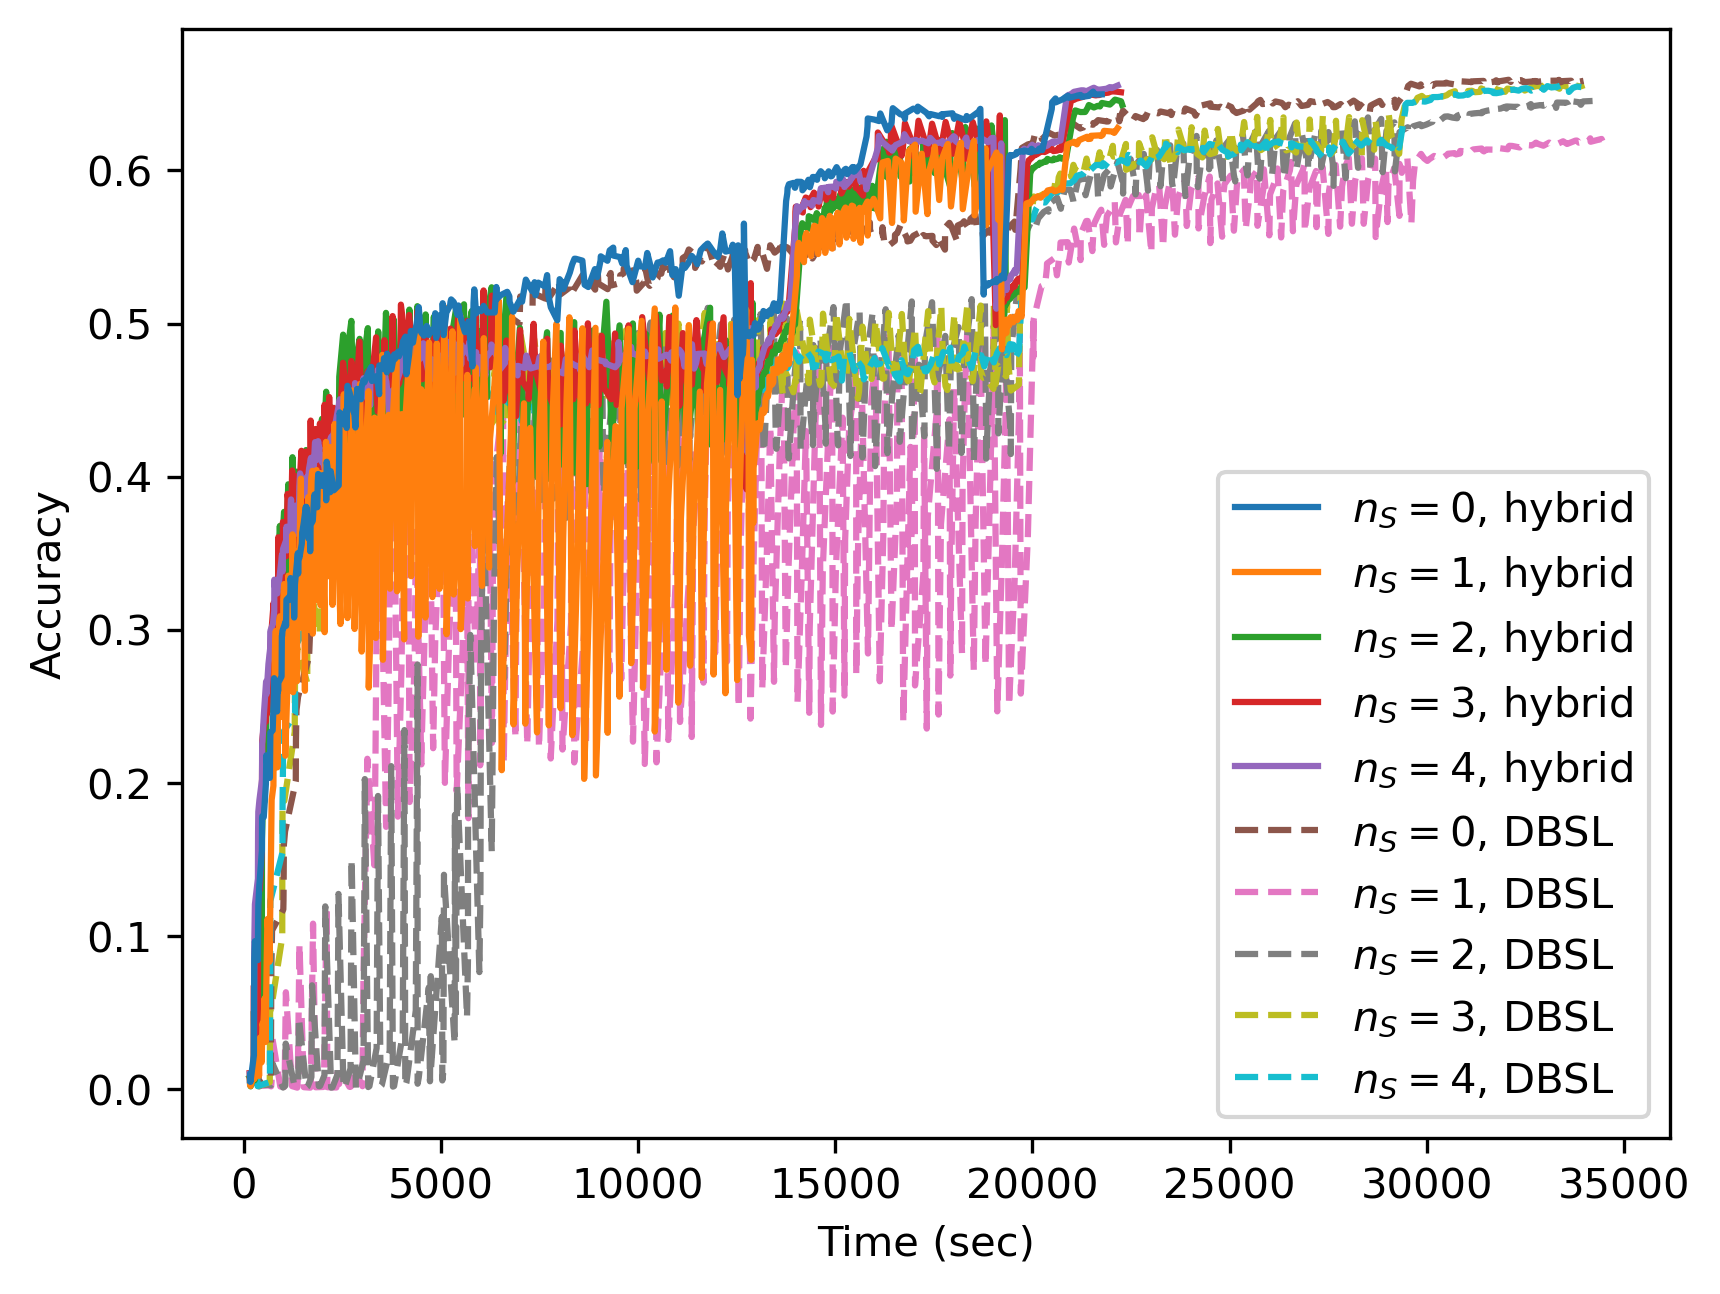

In [8]:
tag = 't105'
feature = 'val_acc'
fig_name = f'{fig_data}_{tag}_{feature}'

plt.figure(dpi=DPI)

plt.plot(npy['journal']['s0']['commit_time'], npy['journal']['s0'][feature],
         label='$n_S=0$, hybrid', zorder=-npy['journal']['s0']['commit_time'][-1])
for key, value in npy['journal'][tag].items():
    plt.plot(value['commit_time'], value[feature],
             label=f'$n_S={key[1]}$, hybrid', zorder=-value['commit_time'][-1])

plt.plot(npy['conf']['s0']['commit_time'], npy['conf']['s0'][feature],
         '--', label='$n_S=0$, DBSL', zorder=-npy['conf']['s0']['commit_time'][-1])
for key, value in npy['conf'][tag].items():
    plt.plot(value['commit_time'], value[feature],
             '--', label=f'$n_S={key[1]}$, DBSL', zorder=-value['commit_time'][-1])


plt.xlabel('Time (sec)')
plt.ylabel('Accuracy')
plt.legend()
None if SAVE else plt.title(fig_name)
plt.savefig(f'{fig_path}/{fig_name}.png', transparent=True) if SAVE else plt.show()

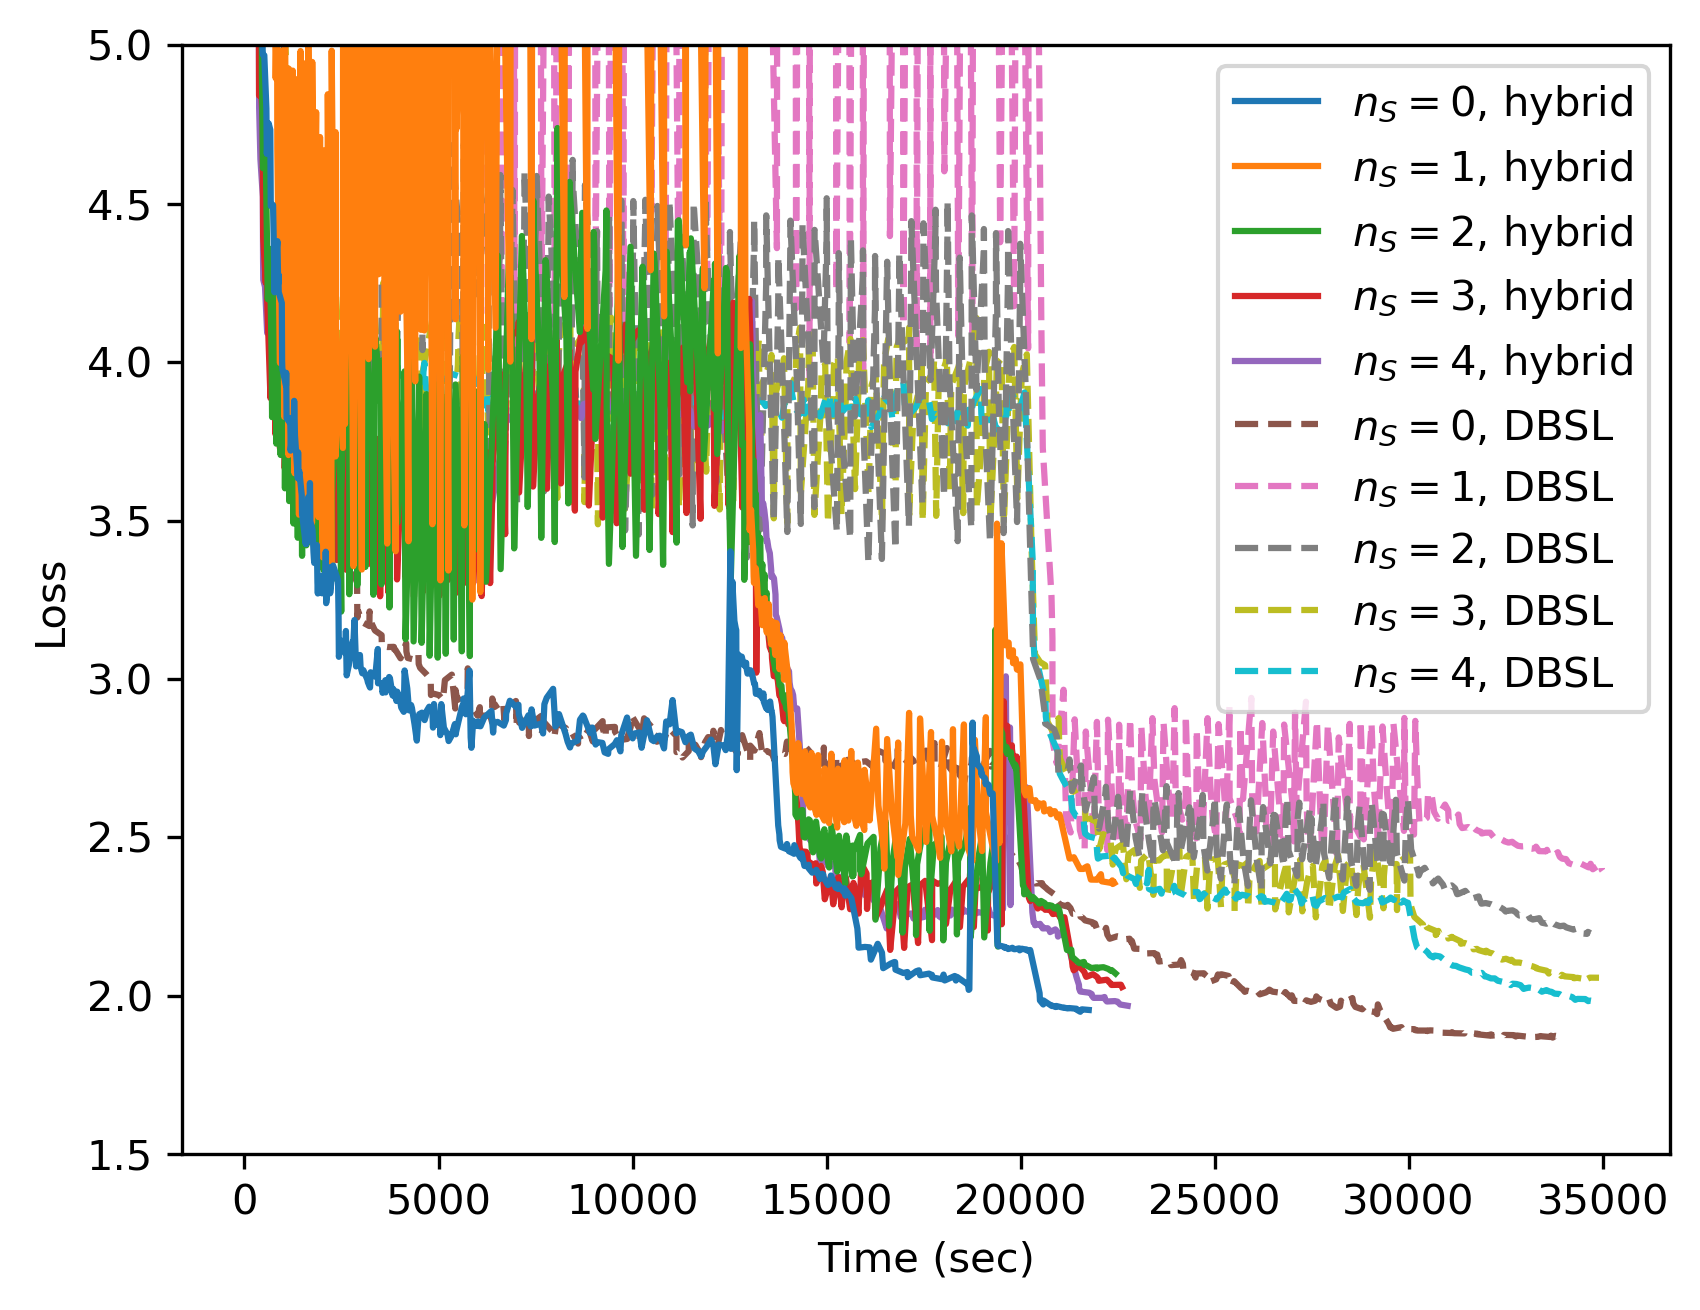

In [9]:
tag = 't110'
feature = 'val_loss'
fig_name = f'{fig_data}_{tag}_{feature}'

plt.figure(dpi=DPI)

plt.plot(npy['journal']['s0']['commit_time'], npy['journal']['s0'][feature],
         label='$n_S=0$, hybrid', zorder=-npy['journal']['s0']['commit_time'][-1])
for key, value in npy['journal'][tag].items():
    plt.plot(value['commit_time'], value[feature],
             label=f'$n_S={key[1]}$, hybrid', zorder=-value['commit_time'][-1])

plt.plot(npy['conf']['s0']['commit_time'], npy['conf']['s0'][feature],
         '--', label='$n_S=0$, DBSL', zorder=-npy['conf']['s0']['commit_time'][-1])
for key, value in npy['conf'][tag].items():
    plt.plot(value['commit_time'], value[feature],
             '--', label=f'$n_S={key[1]}$, DBSL', zorder=-value['commit_time'][-1])

plt.ylim(bottom=1.5, top=5)
plt.xlabel('Time (sec)')
plt.ylabel('Loss')
plt.legend()
None if SAVE else plt.title(fig_name)
plt.savefig(f'{fig_path}/{fig_name}.png', transparent=True) if SAVE else plt.show()

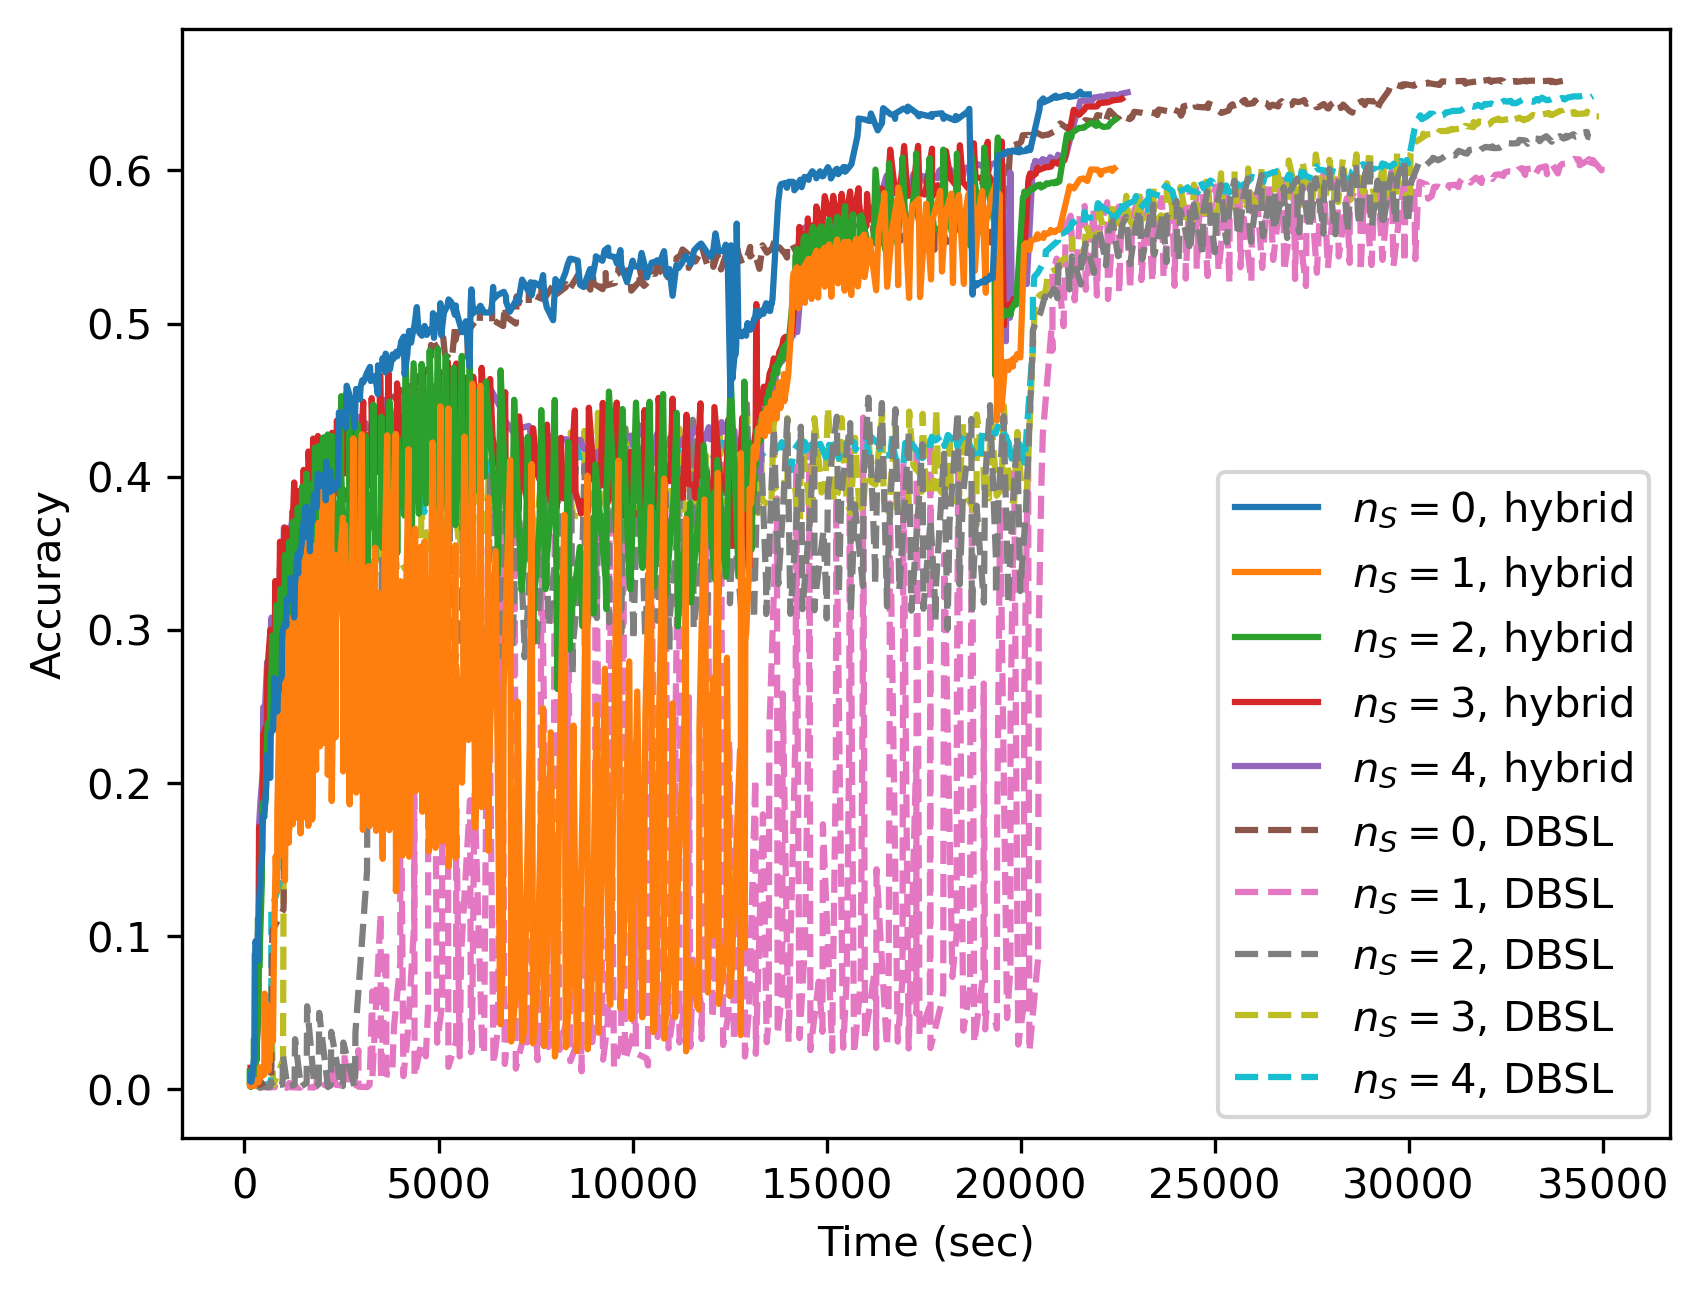

In [10]:
tag = 't110'
feature = 'val_acc'
fig_name = f'{fig_data}_{tag}_{feature}'

plt.figure(dpi=DPI)

plt.plot(npy['journal']['s0']['commit_time'], npy['journal']['s0'][feature],
         label='$n_S=0$, hybrid', zorder=-npy['journal']['s0']['commit_time'][-1])
for key, value in npy['journal'][tag].items():
    plt.plot(value['commit_time'], value[feature],
             label=f'$n_S={key[1]}$, hybrid', zorder=-value['commit_time'][-1])

plt.plot(npy['conf']['s0']['commit_time'], npy['conf']['s0'][feature],
         '--', label='$n_S=0$, DBSL', zorder=-npy['conf']['s0']['commit_time'][-1])
for key, value in npy['conf'][tag].items():
    plt.plot(value['commit_time'], value[feature],
             '--', label=f'$n_S={key[1]}$, DBSL', zorder=-value['commit_time'][-1])

plt.xlabel('Time (sec)')
plt.ylabel('Accuracy')
plt.legend()
None if SAVE else plt.title(fig_name)
plt.savefig(f'{fig_path}/{fig_name}.png', transparent=True) if SAVE else plt.show()